# Purchase Propensity Model

*Predicts whether each customer will purchase in a future 6-month window. This is the first stage of a two-stage CLV pipeline where accurate purchase probabilities feed directly into the dollar-value estimates downstream.*

---

**Business Question:** Given a customer's purchase history, how likely are they to buy again in the next 6 months?

- **Context:** A calibrated purchase probability is the foundation of any CLV estimate. If we can't accurately predict *who* will buy, the downstream revenue estimates are meaningless. This stage isolates the purchase signal before dollar values enter the picture.

**Approach:** We compare four classifiers (Logistic Regression, Random Forest, XGBoost, LightGBM) via cross-validation on training data, tune the CV winner with Bayesian hyperparameter search (Optuna, 50 trials, 3-fold CV on training data only), and calibrate the output probabilities with isotonic regression so they can be used as true purchase likelihoods in the CLV formula. The test set is reserved exclusively for final evaluation: it is never used during model selection or tuning.

**Key Results:**
- Calibrated model achieves Brier score ~0.18 on the held-out test set (well below the 0.25 naive baseline), with PR-AUC ~0.84 (1.6× lift) confirming strong discrimination
- Top-decile customers purchase at ~96% vs. ~14% in the bottom decile (~6.8× lift)
- Behavioral features dominate: recency ratio, recency, frequency, and interpurchase variability are the top drivers

**Inputs / Outputs:**
- Input: `data/processed/clv_data.csv` (from Notebook 01)
- Outputs: 
  - `models/purchase_propensity_model.pkl`, 
  - `models/label_encoders.pkl`
  - `data/processed/stage1_scored.csv` (4,918 customers with calibrated `p_purchase`)

*Output feeds directly into `03_customer_lifetime_value_segmentation.ipynb` (Stage 2).*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    log_loss,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import shap

## Data Dictionary

| Column | Type | Description |
|---|---|---|
| `user_id` | int | Customer identifier |
| `frequency` | int | Number of repeat purchases (total_orders - 1) |
| `recency` | int | Days from last order to calibration end (2011-06-09), standard RFM recency |
| `T` | int | Customer age in days at calibration end (2011-06-09) |
| `monetary_value` | float | Avg order revenue on repeat transactions; falls back to avg_order_value for one-time buyers |
| `total_orders` | int | Total distinct invoices in calibration period |
| `total_spend` | float | Total calibration spend |
| `avg_order_value` | float | Mean order revenue across all calibration orders |
| `unique_products` | int | Distinct StockCodes purchased across calibration |
| `avg_basket_size` | float | Mean distinct products per order |
| `interpurchase_std` | float | Std dev of inter-purchase intervals in days; 0 = one-time buyer (insufficient history) |
| `is_one_time_buyer` | int | Binary flag: 1 if customer made only one purchase in calibration period |
| `cancellation_rate` | float | Fraction of orders that were cancellations (computed from calibration period only) |
| `country` | str | Customer's most frequent country of purchase |
| `actual_holdout_transactions` | int | Distinct invoices in holdout window (2011-06-09 to 2011-12-09) |
| `actual_holdout_revenue` | float | Total revenue in holdout window |
| `purchased_in_holdout` | int | Binary target: 1 if customer made ≥1 holdout purchase |

## 1. Load Data

- We load the 4,918-customer feature matrix produced by the EDA notebook. 
- Each customer has 13 behavioral features and a binary target indicating whether they purchased during the 183-day holdout window.

In [2]:
df = pd.read_csv('../data/processed/clv_data.csv')

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")
df.head()

Loaded 4,918 customers
Positive class (purchased in holdout): 2,557 (52.0%)
Negative class (no holdout purchase):  2,361 (48.0%)


,user_id,frequency,recency,T,monetary_value,total_orders,total_spend,avg_order_value,unique_products,avg_basket_size,interpurchase_std,is_one_time_buyer,cancellation_rate,country,actual_holdout_transactions,actual_holdout_revenue,purchased_in_holdout
0,12346,11,141,541,7046.496364,12,77556.46,6463.038333,27,2.833333,65.426989,0,0.294118,United Kingdom,0,0.00,0
1,12347,3,62,220,607.810000,4,2434.96,608.740000,90,31.000000,16.703293,0,0.000000,Iceland,4,2486.57,1
2,12348,3,64,254,389.080000,4,1388.40,347.100000,24,10.000000,21.377558,0,0.000000,Finland,1,270.00,1
3,12349,1,223,405,1152.620000,2,2221.14,1110.570000,89,50.000000,0.000000,0,0.250000,Italy,1,1457.55,1
4,12350,0,126,126,294.400000,1,294.40,294.400000,16,16.000000,0.000000,1,0.000000,Norway,0,0.00,0


## 2. Feature Engineering

One derived feature is added: **`recency_ratio`** = `recency / T`. A customer who last bought 30 days ago out of a 60-day history (ratio = 0.5) is far more engaged than one who last bought 30 days ago out of 600 days (ratio = 0.05). The ratio normalizes recency by tenure so the model can distinguish these cases directly.

Country encoding is deferred until after the train/test split to prevent information leakage.

In [3]:
# Derived feature: what fraction of customer lifetime has elapsed since last purchase
df['recency_ratio'] = df['recency'] / df['T'].clip(lower=1)

NUMERIC_FEATURES = [
    'frequency', 'recency', 'T', 'monetary_value',
    'avg_order_value',  
    # total_orders,     # excluded (equals frequency + 1, creating an exact linear dependency)
    'unique_products', 'avg_basket_size', 'interpurchase_std',
    'is_one_time_buyer',
    'cancellation_rate',
    'recency_ratio',
]
CATEGORICAL_FEATURES = ['country']
FEATURE_COLS = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]

X_numeric = df[NUMERIC_FEATURES]
y = df['purchased_in_holdout']

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features (12): ['frequency', 'recency', 'T', 'monetary_value', 'avg_order_value', 'unique_products', 'avg_basket_size', 'interpurchase_std', 'is_one_time_buyer', 'cancellation_rate', 'recency_ratio', 'country_enc']
Target distribution: {1: 2557, 0: 2361}


## 3. Train / Test Split

- We set aside 20% of customers (984) as a test set that the model never sees during training, so we can measure how well it performs on genuinely new data. 
- A stratified split (ensuring both halves have the same proportion of buyers and non-buyers) preserves class balance across partitions, while keeping 80% of data available for training and cross-validation.

In [4]:
X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train_num):,} samples ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test_num):,} samples ({y_test.mean():.1%} positive)")

Train: 3,934 samples (52.0% positive)
Test:  984 samples (52.0% positive)


In [5]:
# Label-encode categoricals: fit on training data only, transform all splits
# Unseen categories in test/full data are mapped to -1 (unknown)
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    le.fit(df.loc[X_train_num.index, col].astype(str))
    
    # Transform with unseen-category handling: map unknown labels to -1
    mapping = {label: idx for idx, label in enumerate(le.classes_)}
    df[col + '_enc'] = df[col].astype(str).map(mapping).fillna(-1).astype(int)
    label_encoders[col] = le

n_unseen = (df[CATEGORICAL_FEATURES[0] + '_enc'] == -1).sum()

# Build full feature matrices using the train/test index from the numeric split
X_train = df.loc[X_train_num.index, FEATURE_COLS]
X_test  = df.loc[X_test_num.index, FEATURE_COLS]

print(f"Encoded {len(CATEGORICAL_FEATURES)} categorical feature(s), fit on training data only")
print(f"Unseen categories in test/full data mapped to -1: {n_unseen} customer(s)")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Encoded 1 categorical feature(s), fit on training data only
Unseen categories in test/full data mapped to -1: 1 customer(s)
X_train: (3934, 12), X_test: (984, 12)


**One unseen category (West Indies):** 
- The dataset contains a single customer from West Indies (user 18140, a one-time buyer). 
- With only one customer for that country, the 80/20 stratified split places them entirely in one partition. 
- Since the encoder is fit on training data only, this country is unseen at training time and mapped to -1 (unknown). This is the correct behavior: the model falls back on the other 11 features for this customer, and a single-customer country carries no learnable country-level signal anyway.

## 4. Model Comparison

- We train four different prediction algorithms on the same data and compare their accuracy to find the best one. 
- Comparison uses **3-fold cross-validation on training data only** (a technique that rotates which portion of the training data is used for internal testing, giving a more reliable accuracy estimate than a single pass). 
- The test set is reserved for final evaluation (Section 7). 
- Classes are balanced (52% positive), so no class weighting is applied, and all models use default training settings.

In [6]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', random_state=42, verbosity=0,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1,
    ),
}

# Model selection uses CV on training data. Test set reserved for final eval.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []
trained_models = {}
for name, model in models.items():
    start = time.time()
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1
    )
    train_time = time.time() - start

    results.append({
        'Model': name,
        'CV PR-AUC': cv_scores.mean(),
        'CV PR-AUC Std': cv_scores.std(),
        'Train Time (s)': round(train_time, 1),
    })
    # Fit on full training set for downstream use
    model.fit(X_train, y_train)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('CV PR-AUC', ascending=False)
print("\n=== Model Comparison (3-fold CV on training data) ===")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
default_pr_auc = results_df.iloc[0]['CV PR-AUC']
print(f"\nBest model: {best_model_name} (CV PR-AUC: {default_pr_auc:.4f})")


=== Model Comparison (3-fold CV on training data) ===
              Model  CV PR-AUC  CV PR-AUC Std  Train Time (s)
            XGBoost   0.818213       0.013137             0.8
           LightGBM   0.817476       0.012982             2.2
      Random Forest   0.815099       0.012837             1.0
Logistic Regression   0.811735       0.006935             1.2

Best model: XGBoost (CV PR-AUC: 0.8182)


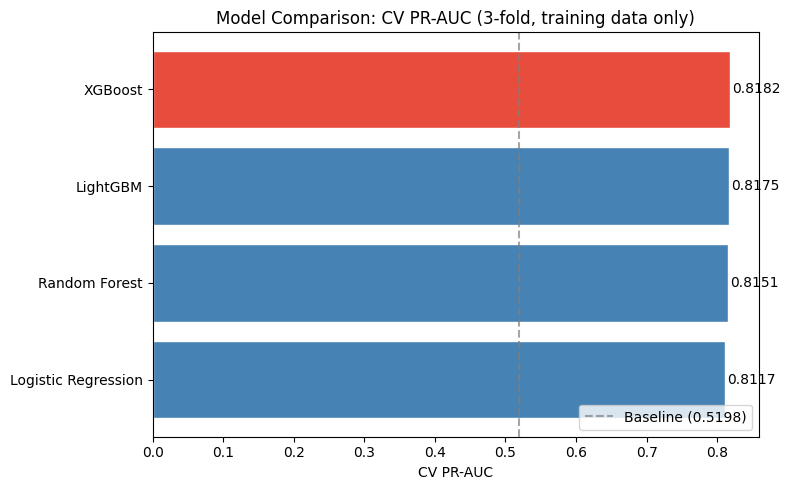

Model selection optimizes discrimination (CV PR-AUC). Calibration is evaluated post-isotonic in Section 7.


In [7]:
# CV PR-AUC comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.sort_values('CV PR-AUC', ascending=True)
colors = ['steelblue' if name != best_model_name else '#e74c3c'
          for name in plot_df['Model']]
bars = ax.barh(plot_df['Model'], plot_df['CV PR-AUC'], color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, plot_df['CV PR-AUC']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

baseline = y_train.mean()
ax.axvline(x=baseline, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline:.4f})')

ax.set_xlabel('CV PR-AUC')
ax.set_title('Model Comparison: CV PR-AUC (3-fold, training data only)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("Model selection optimizes discrimination (CV PR-AUC). Calibration is evaluated post-isotonic in Section 7.")

**All four models perform similarly.** 
- CV PR-AUC ranges from ~0.81 to ~0.82, with differences well within the margin of measurement uncertainty (all models within ~1 percentage point of each other). 
- The margin between XGBoost, LightGBM, and Random Forest is negligible, and any of these three would produce similar downstream CLV estimates. 
- **We proceed with XGBoost as the nominal CV leader;** probability calibration is fixed after training with isotonic regression (Section 6). The CV winner will be tuned with Bayesian hyperparameter search in the next section.

**Two-stage evaluation philosophy:** In short, we pick the model that is best at *ranking* customers, then fix its probability estimates in a separate calibration step.
- **Model selection** uses CV PR-AUC on training data (the best *discriminator* wins). At this stage we want the model that ranks customers most accurately, not the one with the best raw probabilities. The test set is not touched.
- **Final evaluation** (Section 7) uses Brier score on *calibrated* output, because `CLV = P(purchase) × E[revenue]` requires accurate probabilities, not just good rankings.
- This separation works because isotonic calibration (Section 6) can fix raw probability miscalibration via a monotonic transformation (one that adjusts probability values while preserving their rank order), but it cannot fix poor ranking. So we select for the property that can't be fixed after training, then calibrate.

## 5. Hyperparameter Tuning with Optuna

Each model has internal settings (hyperparameters) that affect prediction quality. Optuna's Bayesian search learns from previous trials to focus on promising configurations, exploring 50 combinations via 3-fold CV on training data only. This covers far more ground than grid search while spending fewer evaluations on poor settings.

The test set remains untouched. Tuning against it would inflate reported metrics.

In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Model-specific hyperparameter search spaces ---
MODEL_CLASSES = {
    'LightGBM': lgb.LGBMClassifier,
    'XGBoost': xgb.XGBClassifier,
    'Random Forest': RandomForestClassifier,
    'Logistic Regression': LogisticRegression,
}
FIXED_PARAMS = {
    'LightGBM': {'random_state': 42, 'verbose': -1},
    'XGBoost': {'eval_metric': 'aucpr', 'random_state': 42, 'verbosity': 0},
    'Random Forest': {'random_state': 42, 'n_jobs': -1},
    'Logistic Regression': {'max_iter': 1000, 'random_state': 42},
}

def build_model(trial, model_name):
    """Create a model instance with Optuna-suggested hyperparameters."""
    if model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
    elif model_name == 'Random Forest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }
    elif model_name == 'Logistic Regression':
        params = {
            'C': trial.suggest_float('C', 0.001, 100.0, log=True),
        }

    params.update(FIXED_PARAMS[model_name])
    return MODEL_CLASSES[model_name](**params)


def objective(trial):
    """Optuna objective: 3-fold CV PR-AUC on training data only."""
    model = build_model(trial, best_model_name)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1
    )
    return scores.mean()


print(f"Running Optuna hyperparameter search for {best_model_name} (50 trials, 3-fold CV on train only)...")
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)

print(f"\nBest CV PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# Compare default vs tuned (both on CV, for fair comparison)
print(f"\nDefault CV PR-AUC (train): {default_pr_auc:.4f}")
print(f"Tuned CV PR-AUC (train):   {study.best_value:.4f}")
print(f"Note: Final test-set evaluation follows in Section 7.")

Running Optuna hyperparameter search for XGBoost (50 trials, 3-fold CV on train only)...

Best CV PR-AUC: 0.8324
Best params: {'n_estimators': 100, 'learning_rate': 0.02478997614743224, 'max_depth': 4, 'subsample': 0.6854766254392702, 'colsample_bytree': 0.6685136903410518, 'min_child_weight': 19, 'reg_alpha': 1.4178383324609316e-07, 'reg_lambda': 0.13814773881902792}

Default CV PR-AUC (train): 0.8182
Tuned CV PR-AUC (train):   0.8324
Note: Final test-set evaluation follows in Section 7.


In [9]:
# Retrain with best hyperparameters on the full training set
best_params = study.best_params.copy()
best_params.update(FIXED_PARAMS[best_model_name])

best_clf = MODEL_CLASSES[best_model_name](**best_params)
best_clf.fit(X_train, y_train)

print(f"Tuned {best_model_name} retrained on full training set ({len(X_train):,} samples).")
print(f"Test-set evaluation follows in Section 7 (after calibration).")


Tuned XGBoost retrained on full training set (3,934 samples).
Test-set evaluation follows in Section 7 (after calibration).


## 6. Probability Calibration

A model can rank Customer A above Customer B correctly but still assign wrong percentages (e.g., predicting 80% when the true rate is 60%). Since `CLV = P(purchase) × E[revenue]`, every point of probability error translates directly into dollar error. Calibration fixes the percentages to match real-world purchase rates.

We use **isotonic regression**, which learns a flexible, order-preserving mapping from raw scores to calibrated probabilities without assuming a specific mathematical form. This handles nonlinear miscalibration better than the parametric alternative (Platt/sigmoid scaling).

**Technical detail:** `CalibratedClassifierCV` refits the base model in each of 5 internal CV folds. The final output is an ensemble of 5 (refitted model + isotonic mapper) pairs, each trained on ~80% of training data with the held-out 20% used to learn the mapping.

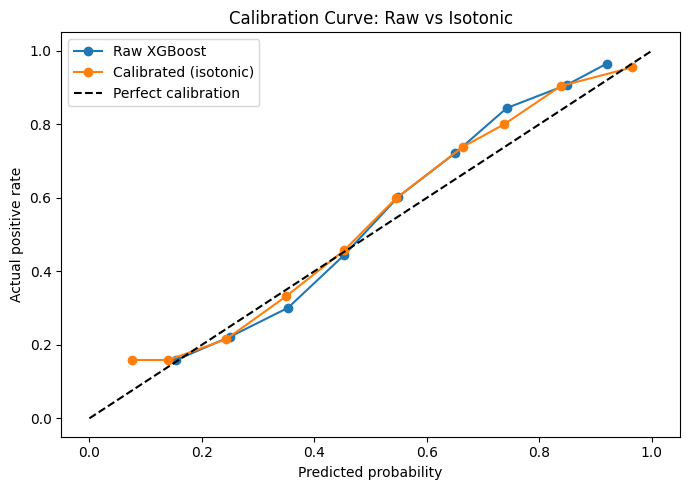

Mean p_purchase (calibrated): 0.4996
Actual base rate (test):      0.5203


In [10]:
cal_clf = CalibratedClassifierCV(best_clf, method='isotonic', cv=5)
cal_clf.fit(X_train, y_train)

# Calibration curve: raw vs calibrated on the test set
y_prob_raw = best_clf.predict_proba(X_test)[:, 1]
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [(f'Raw {best_model_name}', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve: Raw vs Isotonic')
ax.legend()
plt.tight_layout()
plt.show()

# Verify calibration: mean predicted probability should approximate the base rate
print(f"Mean p_purchase (calibrated): {y_prob_cal.mean():.4f}")
print(f"Actual base rate (test):      {y_test.mean():.4f}")

## 7. Model Evaluation

Evaluate the final calibrated model on the held-out test set, then inspect which features drive predictions.

Test-set metrics (calibrated model, generalization performance):
  Brier Score: 0.1760  (baseline: 0.2496, 29% reduction)
  PR-AUC:      0.8389  (baseline: 0.5203, lift: 1.6x)
  Log Loss:    0.5295

  RMSE (probability): 0.4195
  → For a $1,000-revenue customer, this implies ~$420 CLV uncertainty

Brier score is the primary evaluation metric because CLV = P(purchase) × E[revenue]
requires calibrated probabilities. PR-AUC confirms discrimination is preserved post-calibration.


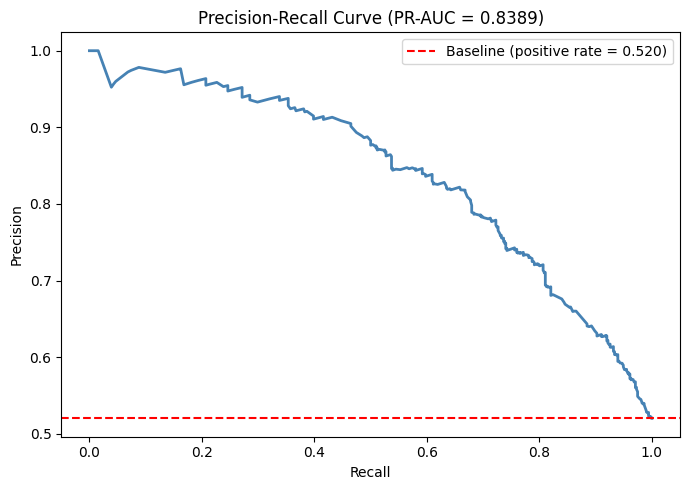

In [11]:
# Final evaluation on the calibrated model using the TEST SET
y_prob = cal_clf.predict_proba(X_test)[:, 1]

brier   = brier_score_loss(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)
baseline = y_test.mean()
brier_baseline = baseline * (1 - baseline)

print("Test-set metrics (calibrated model, generalization performance):")
brier_reduction = 1 - (brier / brier_baseline)
print(f"  Brier Score: {brier:.4f}  (baseline: {brier_baseline:.4f}, {brier_reduction:.0%} reduction)")
print(f"  PR-AUC:      {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"  Log Loss:    {logloss:.4f}")

rmse_prob = np.sqrt(brier)
print(f"\n  RMSE (probability): {rmse_prob:.4f}")
print(f"  → For a $1,000-revenue customer, this implies ~${rmse_prob * 1000:.0f} CLV uncertainty")

print(f"\nBrier score is the primary evaluation metric because CLV = P(purchase) × E[revenue]")
print(f"requires calibrated probabilities. PR-AUC confirms discrimination is preserved post-calibration.")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Baseline (positive rate = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

The calibrated model's probability estimates are accurate on data it has never seen. Two metrics confirm this:

- **Brier score** (how close predicted probabilities are to actual outcomes, lower is better): well below the naive baseline of predicting the average purchase rate for every customer. This is the primary metric because `CLV = P(purchase) × E[revenue]` turns probability errors directly into dollar errors.
- **PR-AUC** (how well the model separates buyers from non-buyers): 1.6× lift over baseline, confirming discrimination is preserved after calibration.

Precision remains above **80% for the top two deciles (~20%)** of predicted customers, making the model suitable for targeted retention campaigns.

=== Decile Analysis (Test Set) ===
        n_customers  actual_rate  avg_prob
decile                                    
1               107       0.1402    0.0950
2                90       0.2111    0.1968
3               116       0.3017    0.3203
4                82       0.3415    0.3557
5                97       0.4227    0.4258
6               102       0.5000    0.5128
7                96       0.6771    0.5790
8                99       0.7778    0.6951
9                98       0.8980    0.8610
10               97       0.9588    0.9796

Top decile purchase rate:    95.9%
Bottom decile purchase rate: 14.0%
Lift (top vs bottom):        6.8x


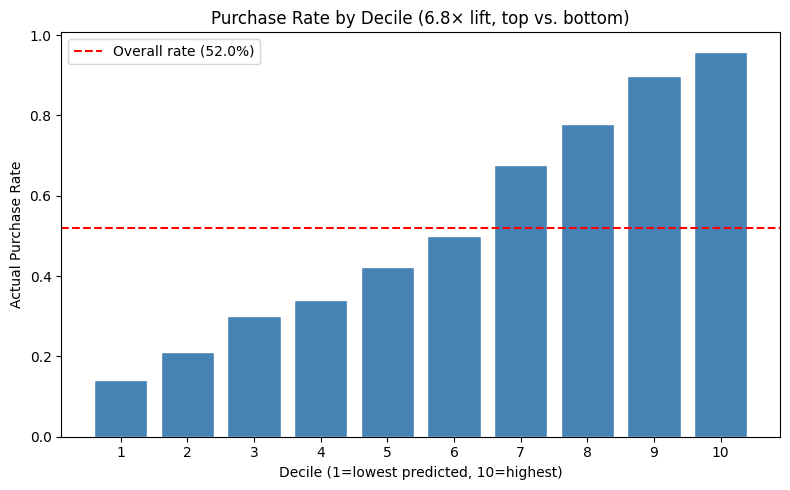

In [12]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers=('y_true', 'count'),
    actual_rate=('y_true', 'mean'),
    avg_prob=('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis (Test Set) ===")
print(decile_stats.to_string())

top_rate = decile_stats.iloc[-1]['actual_rate']
bot_rate = decile_stats.iloc[0]['actual_rate']
lift = top_rate / max(bot_rate, 0.001)

print(f"\nTop decile purchase rate:    {top_rate:.1%}")
print(f"Bottom decile purchase rate: {bot_rate:.1%}")
print(f"Lift (top vs bottom):        {lift:.1f}x")

# Decile bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'], color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Decile (1=lowest predicted, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title(f'Purchase Rate by Decile ({lift:.1f}× lift, top vs. bottom)')
ax.set_xticks(decile_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

The model ranks customers effectively. Purchase rates rise monotonically across deciles:

- **Top decile:** ~96% actually purchase
- **Bottom decile:** ~14% actually purchase
- **Lift:** ~6.8× (top vs. bottom)

This means a campaign targeting only the top 10% of predicted customers would reach buyers at nearly 7× the rate of an untargeted campaign.

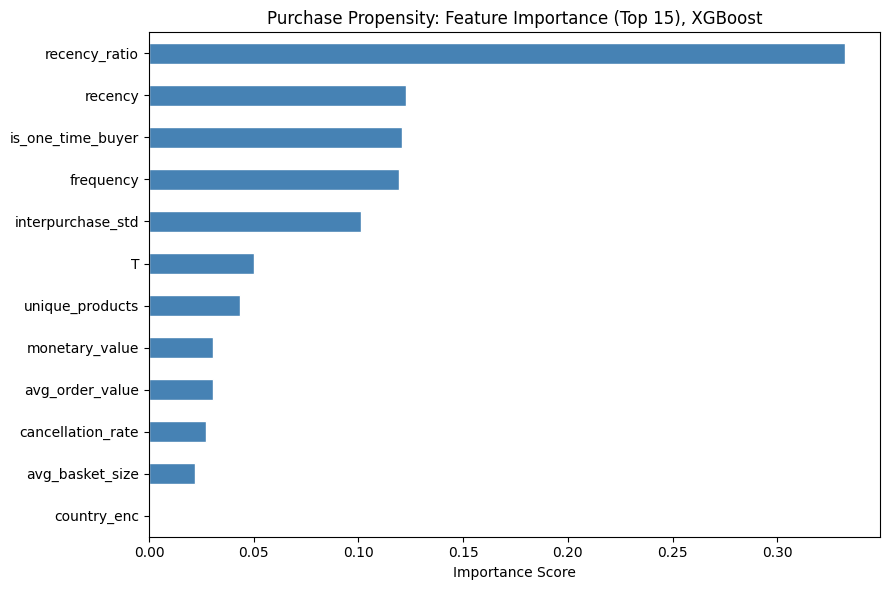

In [13]:
# Feature importance from the base (uncalibrated) tuned classifier
if hasattr(best_clf, 'feature_importances_'):
    importance = pd.Series(best_clf.feature_importances_, index=FEATURE_COLS)
elif hasattr(best_clf, 'coef_'):
    importance = pd.Series(np.abs(best_clf.coef_[0]), index=FEATURE_COLS)
else:
    importance = pd.Series(dtype=float)

top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Purchase Propensity: Feature Importance (Top 15), {best_model_name}')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Interpretation:**

`recency_ratio` is the most-used feature by a wide margin. This chart counts *how often* each feature is used to make a decision, but it doesn't show *which direction* each feature pushes. The SHAP analysis below fills that gap: it reveals whether high or low values of each feature increase or decrease purchase probability.

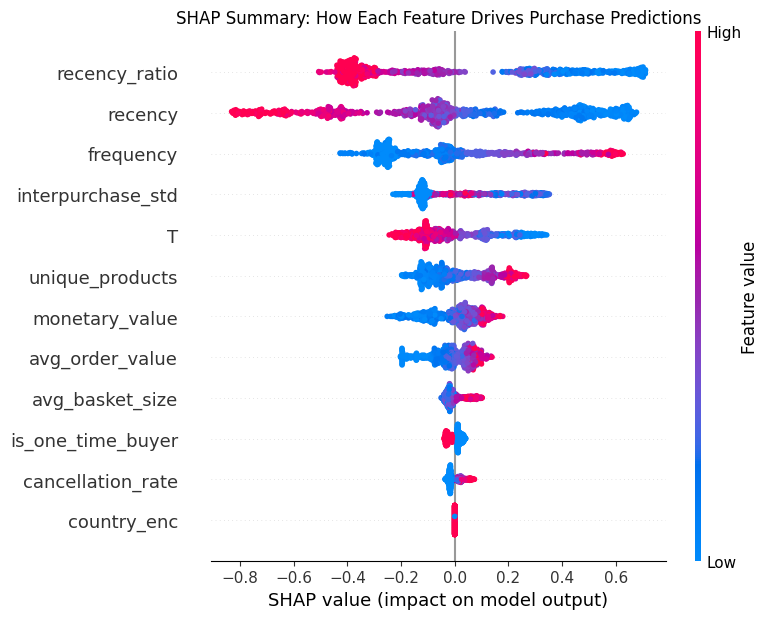

In [14]:
# SHAP values are computed on the base (uncalibrated) model because:
# 1. TreeExplainer requires a single tree-based model, not a CalibratedClassifierCV wrapper
# 2. Isotonic calibration is a monotonic remap that preserves feature-direction relationships
#    (a feature that increases raw score also increases calibrated probability)
#
# Use TreeExplainer for tree-based models, LinearExplainer for linear models
if hasattr(best_clf, 'feature_importances_'):
    explainer = shap.TreeExplainer(best_clf)
else:
    explainer = shap.LinearExplainer(best_clf, X_train)

shap_values = explainer.shap_values(X_test)

# For binary classification, some SHAP versions return [class_0, class_1] list.
# Ensure we use the positive-class (purchase) SHAP values.
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Beeswarm summary plot: feature impact direction and magnitude
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Summary: How Each Feature Drives Purchase Predictions', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**

SHAP values show *how* each feature drives predictions, not just that it matters:

- **`recency_ratio` and `recency`:** The dominant drivers. Customers who have been dormant for a large fraction of their lifetime (high ratio) or simply haven't purchased recently (high recency) are predicted far less likely to buy. These two features capture the same signal at different granularities.
- **`frequency`:** More past purchases increase predicted probability. Repeat buyers keep repeating.
- **`interpurchase_std`:** Customers with erratic purchase timing are less likely to return. Consistency signals loyalty.
- **`cancellation_rate`:** Counterintuitively, high cancellation rates push predictions **upward**. In this wholesale-heavy dataset, cancellations typically come from high-activity buyers adjusting bulk orders. Cancellations signal engagement, not disinterest.

The dependence plot below decomposes the `recency` relationship in detail, showing how the penalty for inactivity accelerates beyond a threshold rather than scaling linearly.

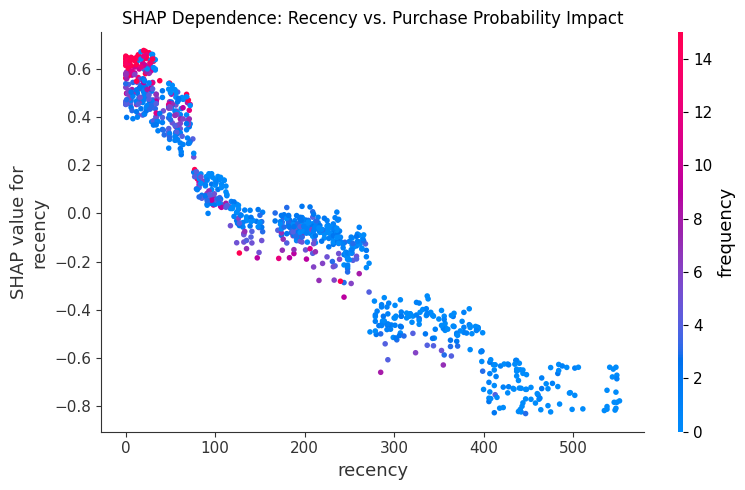

In [15]:
# SHAP dependence plot: how recency drives predictions, colored by strongest interaction
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot('recency', shap_values, X_test, feature_names=FEATURE_COLS, ax=ax, show=False)
ax.set_title('SHAP Dependence: Recency vs. Purchase Probability Impact')
plt.tight_layout()
plt.show()

**Observation:**

The relationship between inactivity and purchase probability isn't a smooth downward slope. It looks more like a cliff. Customers who last bought 30 vs. 60 days ago score almost identically (both are "recently active"). But somewhere around the 100-day mark, predicted probability drops sharply: the customer goes from "probably coming back" to "probably gone."

This cliff pattern is why recency features dominate the model. The signal isn't just "more recent = better." It's that there's a critical window of inactivity beyond which customers are unlikely to return.

## 8. Score All Customers and Save

We apply the calibrated model to all 4,918 customers to produce a purchase probability for each. The scored dataset, trained model, and label encoders are saved for use in the CLV computation notebook (Stage 2) and the Streamlit dashboard.

In [16]:
# Score the entire dataset with calibrated probabilities.
# NOTE: This includes training data, so p_purchase for training customers is
# effectively in-sample. The test-set metrics in Section 7 are the authoritative
# generalization estimates. In-sample scoring is acceptable here because:
#   1. Downstream segmentation thresholds are robust to small probability shifts
#   2. The calibrated model's mean prediction closely tracks the true base rate
#   3. For a production system, cross-validated out-of-fold predictions would be cleaner
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

# Mark which customers were in the test set so downstream consumers
# (dashboard, NB03) can compute Brier score on test-only data
df['is_test'] = df.index.isin(X_test_num.index)

print("p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")
print(f"\nTest set flag: {df['is_test'].sum():,} test / {(~df['is_test']).sum():,} train")

p_purchase distribution:
count    4918.0000
mean        0.5156
std         0.2756
min         0.0000
25%         0.3318
50%         0.4928
75%         0.7187
max         1.0000
Name: p_purchase, dtype: float64

Mean p_purchase: 0.5156 (base rate: 0.5199)

Test set flag: 984 test / 3,934 train


In [17]:
# Save model, label encoders, and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to          models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to    data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to          models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to    data/processed/stage1_scored.csv
  Shape: 4,918 x 21


In [18]:
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity Model")
print("=" * 50)
print(f"Dataset:           UCI Online Retail II")
print(f"Customers scored:  {len(df):,}")
print(f"Best model:        {best_model_name} (tuned with Optuna)")
print(f"Brier Score (test): {brier:.4f}  [primary, calibration accuracy]")
print(f"PR-AUC (test):      {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift)  [secondary, discrimination]")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 03_customer_lifetime_value_segmentation.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity Model
Dataset:           UCI Online Retail II
Customers scored:  4,918
Best model:        XGBoost (tuned with Optuna)
Brier Score (test): 0.1760  [primary, calibration accuracy]
PR-AUC (test):      0.8389 (1.6x lift)  [secondary, discrimination]
Mean p_purchase:   0.5156

Next: 03_customer_lifetime_value_segmentation.ipynb (Stage 2)
